In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from IPython.display import display

RANDOM_STATE = 42

In [6]:
iris = load_iris()
x = iris.data
y = iris.target
class_names = iris.target_names

print("Numbers of flowers: ", len(x))
print("Number of features: ", x.shape[1])
print("Class names: ", class_names)
print("Shape of x: ", x.shape)
print("Shape of y: ", y.shape)

Numbers of flowers:  150
Number of features:  4
Class names:  ['setosa' 'versicolor' 'virginica']
Shape of x:  (150, 4)
Shape of y:  (150,)


In [7]:
flowers = pd.DataFrame(x, columns = iris.feature_names)
flowers['species'] = class_names[y]

display(flowers.head(10))

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


['setosa' 'versicolor' 'virginica']


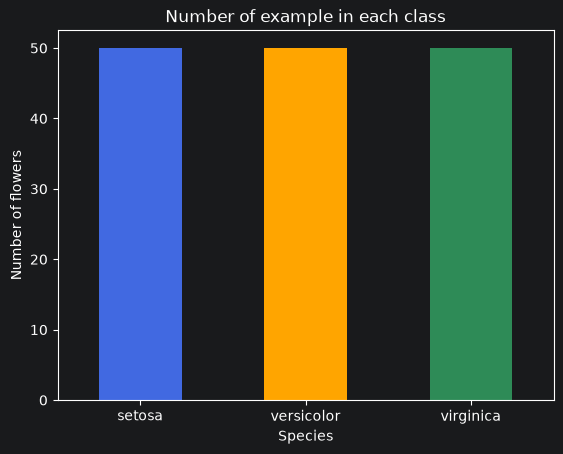

In [8]:
class_counts = flowers['species'].value_counts()
print(class_names)

class_counts.plot(kind='bar', color=['royalblue', 'orange', 'seagreen'])
plt.title("Number of example in each class")
plt.xlabel("Species")
plt.ylabel("Number of flowers")
plt.xticks(rotation = 0)
plt.show()

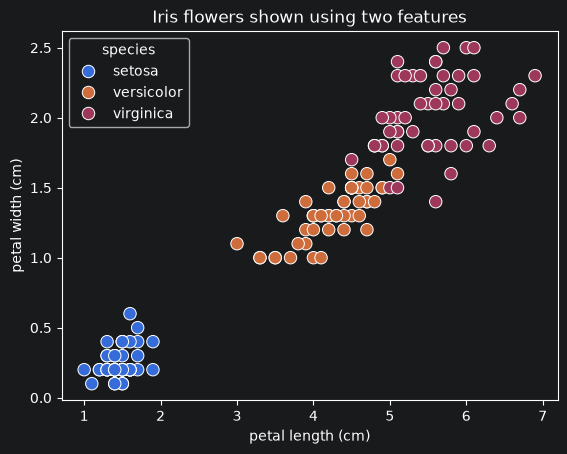

In [9]:
sns.scatterplot(data = flowers, x = "petal length (cm)", y = "petal width (cm)", hue = "species", s = 80)
plt.title("Iris flowers shown using two features")
plt.show()

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = RANDOM_STATE, stratify = y)
print("Number of training examples: ", len(x_train))
print("Number of testing examples: ", len(x_test))
print("Training class counts: ", np.bincount(y_train))
print("Testing class counts: ", np.bincount(y_test))

Number of training examples:  120
Number of testing examples:  30
Training class counts:  [40 40 40]
Testing class counts:  [10 10 10]


In [11]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)
print("First training example: ", x_train[0])
print("First training scaled example: ", x_train_scaled[0].round(3))

First training example:  [4.4 2.9 1.4 0.2]
First training scaled example:  [-1.722 -0.332 -1.346 -1.323]


In [12]:
knn_model = KNeighborsClassifier(n_neighbors=3)
knn_model.fit(x_train_scaled, y_train)
print("The model has been trained")

The model has been trained


In [13]:
y_pred = knn_model.predict(x_test_scaled)
comparison = pd.DataFrame({
    "Correct species": class_names[y_test],
    "Predicted species": class_names[y_pred],
    "Is correct": y_test == y_pred
})
display(comparison)

,Correct species,Predicted species,Is correct
0,setosa,setosa,True
1,virginica,virginica,True
2,versicolor,versicolor,True
3,versicolor,versicolor,True
4,setosa,setosa,True
5,versicolor,versicolor,True
6,setosa,setosa,True
7,setosa,setosa,True
8,virginica,virginica,True
9,versicolor,versicolor,True


In [20]:
knn_report = classification_report(y_pred, y_test)
print(knn_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      0.83      0.91        12
           2       0.80      1.00      0.89         8

    accuracy                           0.93        30
   macro avg       0.93      0.94      0.93        30
weighted avg       0.95      0.93      0.93        30



In [14]:
flower_num = 0
one_flower = x_test_scaled[flower_num].reshape(1, -1)
one_pred = knn_model.predict(one_flower)[0]
print("Original measurements: ", x_test[flower_num])
print("Correct species: ", class_names[y_test[flower_num]])
print("Predicted species: ", class_names[one_pred])

Original measurements:  [4.4 3.  1.3 0.2]
Correct species:  setosa
Predicted species:  setosa


In [15]:
accuracy = accuracy_score(y_test, y_pred)
correct_predictions = np.sum(y_test == y_pred)

print("Correct predictions:", correct_predictions, "out of",
len(y_test))
print("Accuracy:", round(accuracy, 3))
print("Accuracy percentage:", round(accuracy * 100, 1), "%")

Correct predictions: 28 out of 30
Accuracy: 0.933
Accuracy percentage: 93.3 %


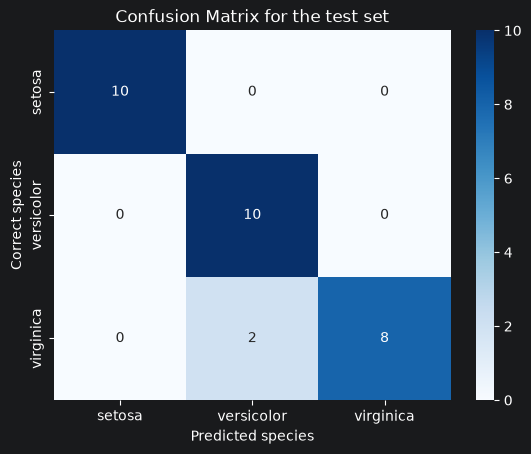

In [16]:
matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted species")
plt.ylabel("Correct species")
plt.title("Confusion Matrix for the test set")
plt.show()

In [17]:
experiment_results = []

for k in [1, 3, 5, 7, 9]:
    knn = KNeighborsClassifier(n_neighbors = k)
    knn.fit(x_train_scaled, y_train)
    experiment_pred = knn.predict(x_test_scaled)

    experiment_accuracy = accuracy_score(y_test, experiment_pred)

    experiment_results.append({
        "k": k,
        "experiment_accuracy": experiment_accuracy
    })

experiment_table = pd.DataFrame(experiment_results)
display(experiment_table)

,k,experiment_accuracy
0,1,0.966667
1,3,0.933333
2,5,0.933333
3,7,0.966667
4,9,0.966667


In [18]:
mlp = MLPClassifier(
    hidden_layer_sizes=(8,),
    max_iter =2000
)
mlp.fit(x_train_scaled, y_train)
mlp_predictions = mlp.predict(x_test_scaled)
mlp_accuracy = accuracy_score(mlp_predictions, y_test)

model_comparison = pd.DataFrame({
    "Model": ["k-NN (k=3)", "Small neural network"],
    "Test accuracy": [accuracy, mlp_accuracy],
})

display(model_comparison.round(3))

,Model,Test accuracy
0,k-NN (k=3),0.933
1,Small neural network,0.967


In [19]:
mlp_report = classification_report(mlp_predictions, y_test)
print(mlp_report)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

